# 🧠 Pipeline EEG — Predição de Crises Epilépticas
## Notebook 2 — Pré-processamento, Rotulagem, EDA, Features e Modelos Baseline

**Datasets:** CHB-MIT · Siena Scalp EEG · SeizeIT2  
**Autor:** Danilo Pedro da Silva Valério

---

| # | Capítulo | Descrição |
|---|---------|-----------|
| 1 | Instalação & Configurações | Dependências e parâmetros globais |
| 2 | Download | CHB-MIT (S3) · Siena (HTTPS) · SeizeIT2 (S3/OpenNeuro) |
| 3 | Parsers de Anotações | Sumários/Seizure-lists → intervalos de crise em segundos |
| 4 | Carregamento & EDA | Leitura EDF, plots de sinal, PSD, qualidade |
| 5 | Pré-processamento | Notch + Passa-alta + Passa-baixa |
| 6 | Rotulagem Temporal | Interictal / Pré-ictal / Ictal / Pós-ictal |
| 7 | Janelamento | 4 s · 50 % overlap · label majoritário |
| 8 | Salvamento Nível 1 | NPZ por arquivo (sinal filtrado + labels amostra-a-amostra) |
| 9 | Salvamento Nível 2 | NPZ por paciente (janelas + labels de janela) |
| 10 | Extração de Features | Temporal · Espectral · Não-linear |
| 11 | Modelos Baseline | LOSO-CV — Random Forest · SVM · 1D-CNN |
| 12 | Resultados | Métricas por paciente e resumo global |

---
# Capítulo 1 — Instalação e Configurações

In [1]:
%pip install mne scipy numpy pandas matplotlib seaborn PyWavelets tqdm boto3 botocore \
             scikit-learn xgboost torch --quiet
print("✅ Dependências instaladas")

Note: you may need to restart the kernel to use updated packages.
✅ Dependências instaladas



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, json, warnings, gc, html
import html.parser
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mne
import pywt
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from scipy.signal  import butter, sosfiltfilt, iirnotch, filtfilt, welch
from scipy.stats   import kurtosis as sp_kurtosis, skew as sp_skew
from tqdm.auto     import tqdm

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
print("✅ Imports OK")

✅ Imports OK


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 Configurações Globais

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Diretórios ────────────────────────────────────────────────────────────────
ROOT_DIR    = 'data'
CHBMIT_DIR  = os.path.join(ROOT_DIR, 'chb-mit')
SIENA_DIR   = os.path.join(ROOT_DIR, 'siena')
SEIZEIT_DIR = os.path.join(ROOT_DIR, 'seizeit2')
L1_DIR      = os.path.join(ROOT_DIR, 'level1_signals')   # sinal filtrado + labels/amostra
L2_DIR      = os.path.join(ROOT_DIR, 'level2_windows')   # janelas + labels/janela
FEAT_DIR    = os.path.join(ROOT_DIR, 'features')
for d in [CHBMIT_DIR, SIENA_DIR, SEIZEIT_DIR, L1_DIR, L2_DIR, FEAT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Parâmetros de filtragem ───────────────────────────────────────────────────
F_HP       = 0.5    # Hz  passa-alta
F_LP       = 40.0   # Hz  passa-baixa
F_ORDER    = 4      # ordem Butterworth
# Notch por dataset (Hz)
NOTCH = {'CHBMIT': 60.0, 'Siena': 50.0, 'SeizeIT2': 50.0}

# ── Janelamento ───────────────────────────────────────────────────────────────
WIN_SEC  = 4      # segundos
OVERLAP  = 0.50   # 50 % de sobreposição

# ── Rotulagem ─────────────────────────────────────────────────────────────────
PRE_SEC   = 10 * 60   # 10 min antes  → pré-ictal
POST_SEC  = 10 * 60   # 10 min depois → pós-ictal
IGAP_SEC  = 10 * 60   # margem de segurança para interictal

# Labels
LBL = dict(interictal=0, preictal=1, ictal=2, postictal=3, unknown=-1)
LBL_NAMES = {v: k for k, v in LBL.items()}

# ── Pacientes piloto (teste rápido) ───────────────────────────────────────────
PILOT = {'CHBMIT': 'chb01', 'Siena': 'PN00', 'SeizeIT2': 'sub-001'}

print("✅ Configurações OK")
for k, v in NOTCH.items(): print(f"   Notch {k:10s}: {v} Hz")
print(f"   Banda       : {F_HP}–{F_LP} Hz")
print(f"   Janela      : {WIN_SEC} s · overlap {int(OVERLAP*100)} %")
print(f"   Pré-ictal   : {PRE_SEC//60} min | Pós-ictal: {POST_SEC//60} min")

✅ Configurações OK
   Notch CHBMIT    : 60.0 Hz
   Notch Siena     : 50.0 Hz
   Notch SeizeIT2  : 50.0 Hz
   Banda       : 0.5–40.0 Hz
   Janela      : 4 s · overlap 50 %
   Pré-ictal   : 10 min | Pós-ictal: 10 min


---
# Capítulo 2 — Download dos Dados

## 2.1 CHB-MIT via S3 (PhysioNet Open Data)

Bucket `physionet-open`. Baixa apenas os EDFs do paciente piloto listados em `RECORDS-WITH-SEIZURES`.

In [5]:
def s3_client():
    return boto3.client('s3', region_name='us-east-1',
                        config=Config(signature_version=UNSIGNED))

def download_chbmit_patient(patient=PILOT['CHBMIT'], local_root=CHBMIT_DIR):
    s3      = s3_client()
    bucket  = 'physionet-open'
    prefix  = 'chbmit/1.0.0/'
    pat_dir = os.path.join(local_root, patient)
    os.makedirs(pat_dir, exist_ok=True)

    # RECORDS-WITH-SEIZURES
    rec_local = os.path.join(local_root, 'RECORDS-WITH-SEIZURES')
    if not os.path.exists(rec_local):
        print("⬇️  Baixando RECORDS-WITH-SEIZURES ...")
        s3.download_file(bucket, prefix + 'RECORDS-WITH-SEIZURES', rec_local)

    with open(rec_local) as f:
        all_recs = [l.strip() for l in f if l.strip().startswith(patient + '/')]

    # summary.txt
    sum_key   = f'{prefix}{patient}/{patient}-summary.txt'
    sum_local = os.path.join(pat_dir, f'{patient}-summary.txt')
    if not os.path.exists(sum_local):
        print(f"⬇️  {patient}-summary.txt ...")
        s3.download_file(bucket, sum_key, sum_local)

    # EDFs
    downloaded = 0
    for rec in tqdm(all_recs, desc=f'CHB-MIT {patient}'):
        fname = rec.split('/')[-1]
        local = os.path.join(pat_dir, fname)
        if not os.path.exists(local):
            try:
                s3.download_file(bucket, prefix + rec, local)
                downloaded += 1
            except Exception as e:
                print(f"  ⚠️  {rec}: {e}")
    print(f"✅ {patient} — {len(all_recs)} EDFs com crise | {downloaded} novos")
    return pat_dir

chbmit_dir = download_chbmit_patient()

⬇️  Baixando RECORDS-WITH-SEIZURES ...
⬇️  chb01-summary.txt ...


CHB-MIT chb01: 100%|██████████| 7/7 [00:55<00:00,  7.94s/it]

✅ chb01 — 7 EDFs com crise | 7 novos


## 2.2 Siena via HTTPS (PhysioNet)

In [6]:
SIENA_BASE = 'https://physionet.org/files/siena-scalp-eeg/1.0.0/'

class _LinkParser(html.parser.HTMLParser):
    def __init__(self):
        super().__init__()
        self.links = []
    def handle_starttag(self, tag, attrs):
        if tag == 'a':
            for attr, val in attrs:
                if attr == 'href' and not val.startswith(('?','/','..')):
                    self.links.append(val)

def download_siena_patient(patient=PILOT['Siena'], local_root=SIENA_DIR):
    pat_dir  = os.path.join(local_root, patient)
    os.makedirs(pat_dir, exist_ok=True)
    base_url = SIENA_BASE + patient + '/'

    try:
        with urllib.request.urlopen(base_url, timeout=20) as r:
            content = r.read().decode('utf-8')
    except Exception as e:
        print(f"⚠️  Não foi possível listar {base_url}: {e}")
        return pat_dir

    p = _LinkParser(); p.feed(content)
    files = [l for l in p.links if l.endswith('.edf') or l.endswith('.txt')]

    downloaded = 0
    for fname in tqdm(files, desc=f'Siena {patient}'):
        local = os.path.join(pat_dir, fname)
        if not os.path.exists(local):
            try:
                urllib.request.urlretrieve(base_url + fname, local)
                downloaded += 1
            except Exception as e:
                print(f"  ⚠️  {fname}: {e}")
    print(f"✅ Siena {patient} — {len(files)} arquivos | {downloaded} novos")
    return pat_dir

siena_dir = download_siena_patient()

Siena PN00: 100%|██████████| 6/6 [37:20<00:00, 373.34s/it]

✅ Siena PN00 — 6 arquivos | 6 novos


## 2.3 SeizeIT2 via S3 (OpenNeuro)

In [7]:
SEIZEIT_BUCKET  = 'openneuro.org'
SEIZEIT_DATASET = 'ds005873'
SEIZEIT_SESSION = 'ses-01'

def download_seizeit2_subject(subject=PILOT['SeizeIT2'],
                               local_root=SEIZEIT_DIR):
    s3      = s3_client()
    prefix  = f'{SEIZEIT_DATASET}/{subject}/{SEIZEIT_SESSION}/eeg/'
    sub_dir = os.path.join(local_root, subject, SEIZEIT_SESSION, 'eeg')
    os.makedirs(sub_dir, exist_ok=True)

    paginator = s3.get_paginator('list_objects_v2')
    keys = []
    for page in paginator.paginate(Bucket=SEIZEIT_BUCKET, Prefix=prefix):
        keys.extend(o['Key'] for o in page.get('Contents', []))

    downloaded = 0
    for key in tqdm(keys, desc=f'SeizeIT2 {subject}'):
        fname = key.split('/')[-1]
        local = os.path.join(sub_dir, fname)
        if not os.path.exists(local):
            try:
                s3.download_file(SEIZEIT_BUCKET, key, local)
                downloaded += 1
            except Exception as e:
                print(f"  ⚠️  {fname}: {e}")
    print(f"✅ SeizeIT2 {subject} — {len(keys)} arquivos | {downloaded} novos")
    return sub_dir

seizeit_dir = download_seizeit2_subject()

SeizeIT2 sub-001: 100%|██████████| 27/27 [01:40<00:00,  3.72s/it]

✅ SeizeIT2 sub-001 — 27 arquivos | 27 novos


---
# Capítulo 3 — Parsers de Anotações de Crise

## 3.1 Parser CHB-MIT (`chbXX-summary.txt`)

O sumário lista, para cada EDF, o número de crises e os tempos de início/fim em **segundos**.

In [8]:
def parse_chbmit_summary(patient_dir, patient):
    """
    Retorna dict: { 'chb01_03.edf': [(start_s, end_s), ...], ... }
    Apenas arquivos com ≥ 1 crise completa.
    """
    path = os.path.join(patient_dir, f'{patient}-summary.txt')
    seizures = {}
    cur_file, n_seiz = None, 0

    with open(path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            if line.startswith('File Name:'):
                cur_file = line.split(':', 1)[1].strip()
                n_seiz   = 0
            elif line.startswith('Number of Seizures in File:'):
                n_seiz = int(line.split(':', 1)[1].strip())
                if n_seiz > 0:
                    seizures.setdefault(cur_file, [])
            elif cur_file and n_seiz > 0:
                if 'Seizure' in line and 'Start Time' in line:
                    t = int(re.search(r'(\d+)', line.split(':',1)[1]).group(1))
                    seizures[cur_file].append([t, None])
                elif 'Seizure' in line and 'End Time' in line:
                    t = int(re.search(r'(\d+)', line.split(':',1)[1]).group(1))
                    if seizures[cur_file] and seizures[cur_file][-1][1] is None:
                        seizures[cur_file][-1][1] = t

    return {f: [(s,e) for s,e in lst if e is not None]
            for f, lst in seizures.items()
            if any(e is not None for s,e in lst)}

chbmit_ann = parse_chbmit_summary(
    os.path.join(CHBMIT_DIR, PILOT['CHBMIT']), PILOT['CHBMIT'])

print(f"✅ CHB-MIT {PILOT['CHBMIT']} — {len(chbmit_ann)} arquivos com crise")
for fname, seiz in chbmit_ann.items():
    for s,e in seiz:
        print(f"   {fname}  →  {s}s – {e}s  ({e-s}s)")

✅ CHB-MIT chb01 — 7 arquivos com crise
   chb01_03.edf  →  2996s – 3036s  (40s)
   chb01_04.edf  →  1467s – 1494s  (27s)
   chb01_15.edf  →  1732s – 1772s  (40s)
   chb01_16.edf  →  1015s – 1066s  (51s)
   chb01_18.edf  →  1720s – 1810s  (90s)
   chb01_21.edf  →  327s – 420s  (93s)
   chb01_26.edf  →  1862s – 1963s  (101s)


## 3.2 Parser Siena (`Seizures-list-PNXX.txt`)

Formato Siena: os tempos são fornecidos como **horário do relógio** (`HH.MM.SS`).  
Convertemos para **segundos relativos ao início da gravação** usando o campo `Registration start time`.

In [9]:
def _hms_to_sec(s):
    """Converte 'HH.MM.SS' ou 'HH:MM:SS' para segundos inteiros."""
    s = s.strip().replace(':', '.')
    parts = s.split('.')
    if len(parts) == 3:
        h, m, sec = int(parts[0]), int(parts[1]), int(parts[2])
        return h * 3600 + m * 60 + sec
    return 0

def _clock_offset(reg_start_s, event_s):
    """
    Calcula offset em segundos de event_s em relação a reg_start_s,
    tratando cruzamento de meia-noite (event_s < reg_start_s).
    """
    diff = event_s - reg_start_s
    if diff < 0:          # passou da meia-noite
        diff += 24 * 3600
    return diff

def parse_siena_seizure_list(patient_dir, patient):
    """
    Lê Seizures-list-PNXX.txt e retorna:
        { 'PN00-1.edf': [(start_rel_s, end_rel_s), ...], ... }
    Os tempos são relativos ao início da gravação de cada arquivo.
    """
    fname_txt = f'Seizures-list-{patient}.txt'
    path = os.path.join(patient_dir, fname_txt)
    if not os.path.exists(path):
        print(f"⚠️  {fname_txt} não encontrado em {patient_dir}")
        return {}

    seizures   = {}
    cur_file   = None
    reg_start  = None

    with open(path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            m = re.match(r'File name:\s*(\S+\.edf)', line, re.IGNORECASE)
            if m:
                cur_file  = m.group(1).strip()
                reg_start = None
                seizures.setdefault(cur_file, [])
                continue

            m = re.match(r'Registration start time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m:
                reg_start = _hms_to_sec(m.group(1))
                continue

            m = re.match(r'Seizure start time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m and cur_file is not None and reg_start is not None:
                t = _clock_offset(reg_start, _hms_to_sec(m.group(1)))
                seizures[cur_file].append([t, None])
                continue

            m = re.match(r'Seizure end time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m and cur_file is not None and reg_start is not None:
                t = _clock_offset(reg_start, _hms_to_sec(m.group(1)))
                if seizures[cur_file] and seizures[cur_file][-1][1] is None:
                    seizures[cur_file][-1][1] = t

    return {f: [(s,e) for s,e in lst if e is not None and e > s]
            for f, lst in seizures.items()
            if any(e is not None and e > s for s,e in lst)}

siena_ann = parse_siena_seizure_list(
    os.path.join(SIENA_DIR, PILOT['Siena']), PILOT['Siena'])

print(f"✅ Siena {PILOT['Siena']} — {len(siena_ann)} arquivos com crise")
for fname, seiz in siena_ann.items():
    for s,e in seiz:
        print(f"   {fname}  →  {s}s – {e}s  ({e-s}s)")

✅ Siena PN00 — 5 arquivos com crise
   PN00-1.edf  →  1143s – 1213s  (70s)
   PN00-2.edf  →  1220s – 1274s  (54s)
   PN00-3.edf  →  765s – 4425s  (3660s)
   PN00-4.edf  →  1006s – 1080s  (74s)
   PN00-5.edf  →  904s – 971s  (67s)


## 3.3 Parser SeizeIT2 (BIDS `_events.tsv`)

O SeizeIT2 segue o padrão BIDS: cada EDF `_eeg.edf` tem um `_events.tsv` associado
com colunas `onset`, `duration` e `eventType` (crises têm `eventType` começando com `sz`).

In [10]:
def parse_seizeit2_subject(subject_eeg_dir):
    """
    Varre todos os *_events.tsv do sujeito e retorna:
        { 'sub-001_ses-01_task-szMonitoring_run-01_eeg.edf':
            [(onset_s, onset_s + duration_s), ...], ... }
    """
    seizures = {}
    tsv_files = sorted(f for f in os.listdir(subject_eeg_dir)
                       if f.endswith('_events.tsv'))
    for tsv in tsv_files:
        edf_name = tsv.replace('_events.tsv', '_eeg.edf')
        try:
            df = pd.read_csv(os.path.join(subject_eeg_dir, tsv), sep='\t')
        except Exception:
            continue
        # Crises: eventType começa com 'sz'
        sz = df[df['eventType'].astype(str).str.lower().str.startswith('sz')]
        if sz.empty:
            continue
        pairs = [(float(row['onset']),
                  float(row['onset']) + float(row['duration']))
                 for _, row in sz.iterrows()
                 if float(row['duration']) > 0]
        if pairs:
            seizures[edf_name] = pairs
    return seizures

seizeit_ann = parse_seizeit2_subject(seizeit_dir)
print(f"✅ SeizeIT2 {PILOT['SeizeIT2']} — {len(seizeit_ann)} arquivos com crise")
for fname, seiz in seizeit_ann.items():
    for s,e in seiz:
        print(f"   {os.path.basename(fname)}  →  {s:.1f}s – {e:.1f}s  ({e-s:.1f}s)")

✅ SeizeIT2 sub-001 — 4 arquivos com crise
   sub-001_ses-01_task-szMonitoring_run-03_eeg.edf  →  57975.0s – 58047.0s  (72.0s)
   sub-001_ses-01_task-szMonitoring_run-05_eeg.edf  →  60968.0s – 61049.0s  (81.0s)
   sub-001_ses-01_task-szMonitoring_run-07_eeg.edf  →  16300.0s – 16443.0s  (143.0s)
   sub-001_ses-01_task-szMonitoring_run-08_eeg.edf  →  28285.0s – 28310.0s  (25.0s)


---
# Capítulo 4 — Carregamento & EDA

In [11]:
_NON_EEG = {'ecg','emg','acc','gyr','mov','resp','ekg','eog','chest','abd',
            'eda','temp','bvp','hr','ppg'}

def load_edf(path, scale_uv=True):
    """
    Carrega EDF, mantém apenas canais EEG.
    Retorna (data: (n_ch, n_samp), sfreq, ch_names, duration_s).
    """
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    try:
        raw.pick('eeg')
    except Exception:
        keep = [c for c in raw.ch_names
                if not any(p in c.lower() for p in _NON_EEG)]
        if keep:
            raw.pick(keep)
    data  = raw.get_data() * (1e6 if scale_uv else 1.0)
    sfreq = float(raw.info['sfreq'])
    return data, sfreq, list(raw.ch_names), data.shape[1] / sfreq

In [12]:
# ── Carrega 1 arquivo de cada dataset para EDA ────────────────────────────────
datasets_eda = {}

# CHB-MIT
first_chb = list(chbmit_ann.keys())[0]
path_chb  = os.path.join(CHBMIT_DIR, PILOT['CHBMIT'], first_chb)
if os.path.exists(path_chb):
    d, sf, ch, dur = load_edf(path_chb)
    datasets_eda['CHB-MIT'] = dict(data=d, sfreq=sf, ch=ch, dur=dur,
                                   fname=first_chb, seiz=chbmit_ann[first_chb],
                                   notch=NOTCH['CHBMIT'])
    print(f"✅ CHB-MIT · {first_chb}: {d.shape}  fs={sf}Hz  dur={dur:.0f}s")

# Siena
if siena_ann:
    first_sn = list(siena_ann.keys())[0]
    path_sn  = os.path.join(SIENA_DIR, PILOT['Siena'], first_sn)
    if os.path.exists(path_sn):
        d, sf, ch, dur = load_edf(path_sn)
        datasets_eda['Siena'] = dict(data=d, sfreq=sf, ch=ch, dur=dur,
                                     fname=first_sn, seiz=siena_ann[first_sn],
                                     notch=NOTCH['Siena'])
        print(f"✅ Siena   · {first_sn}: {d.shape}  fs={sf}Hz  dur={dur:.0f}s")

# SeizeIT2
if seizeit_ann:
    first_sz = list(seizeit_ann.keys())[0]
    path_sz  = os.path.join(seizeit_dir, first_sz)
    if os.path.exists(path_sz):
        d, sf, ch, dur = load_edf(path_sz)
        datasets_eda['SeizeIT2'] = dict(data=d, sfreq=sf, ch=ch, dur=dur,
                                        fname=first_sz, seiz=seizeit_ann[first_sz],
                                        notch=NOTCH['SeizeIT2'])
        print(f"✅ SeizeIT2· {os.path.basename(first_sz)}: {d.shape}  fs={sf}Hz  dur={dur:.0f}s")

✅ CHB-MIT · chb01_03.edf: (23, 921600)  fs=256.0Hz  dur=3600s
✅ Siena   · PN00-1.edf: (35, 1344000)  fs=512.0Hz  dur=2625s
✅ SeizeIT2· sub-001_ses-01_task-szMonitoring_run-03_eeg.edf: (2, 16634624)  fs=256.0Hz  dur=64979s


## 4.1 Plot do Sinal Bruto com Marcação Ictal

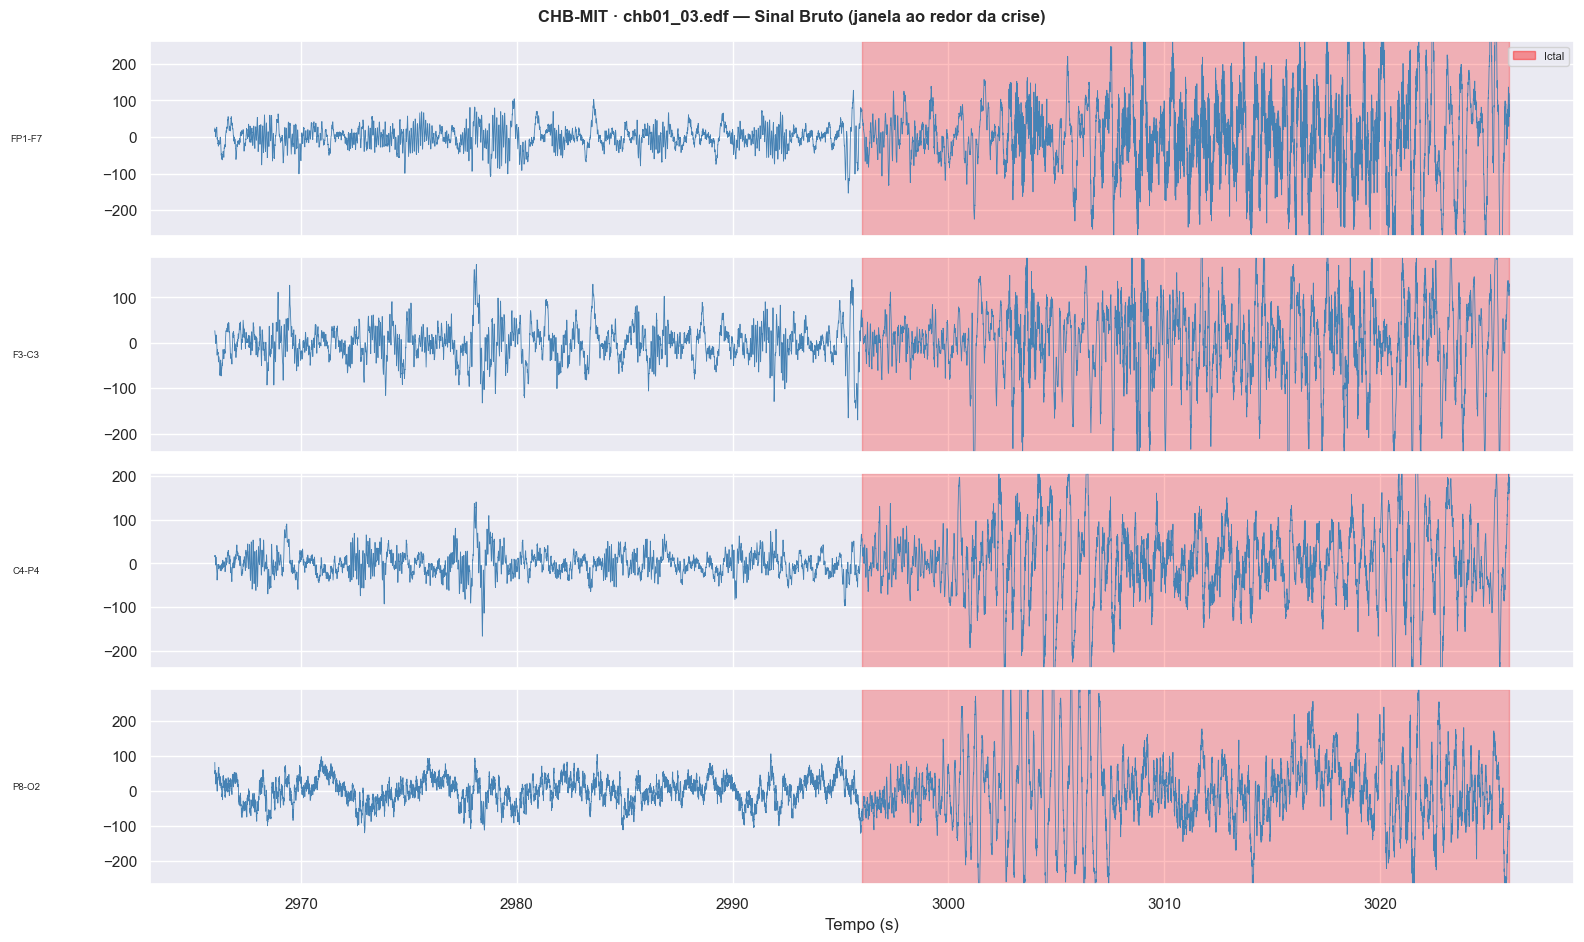

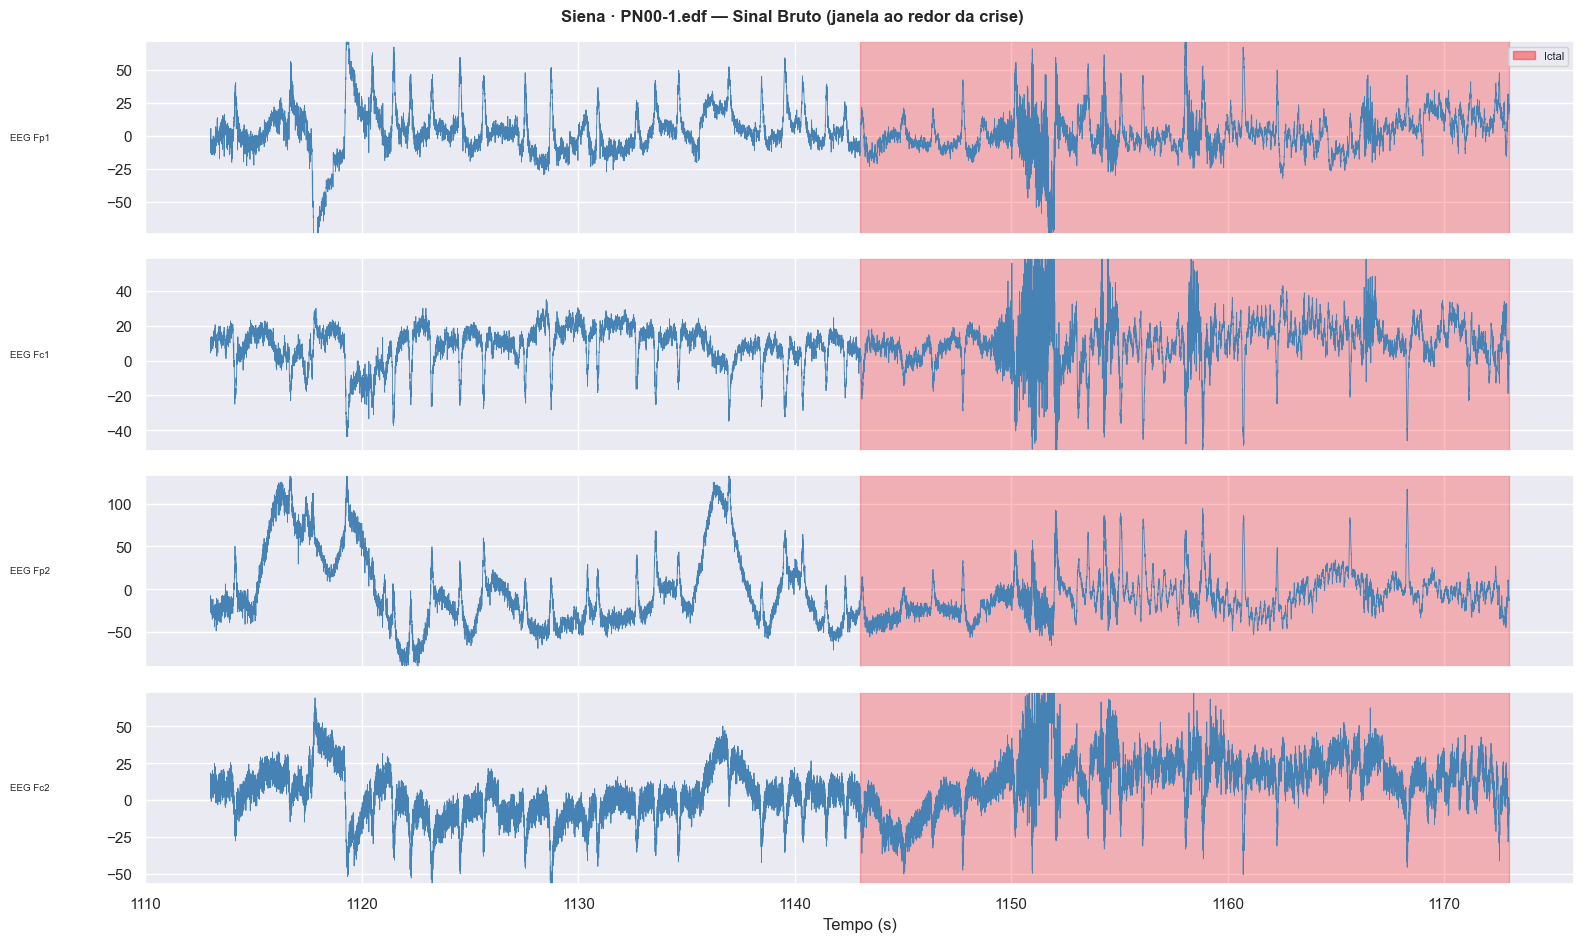

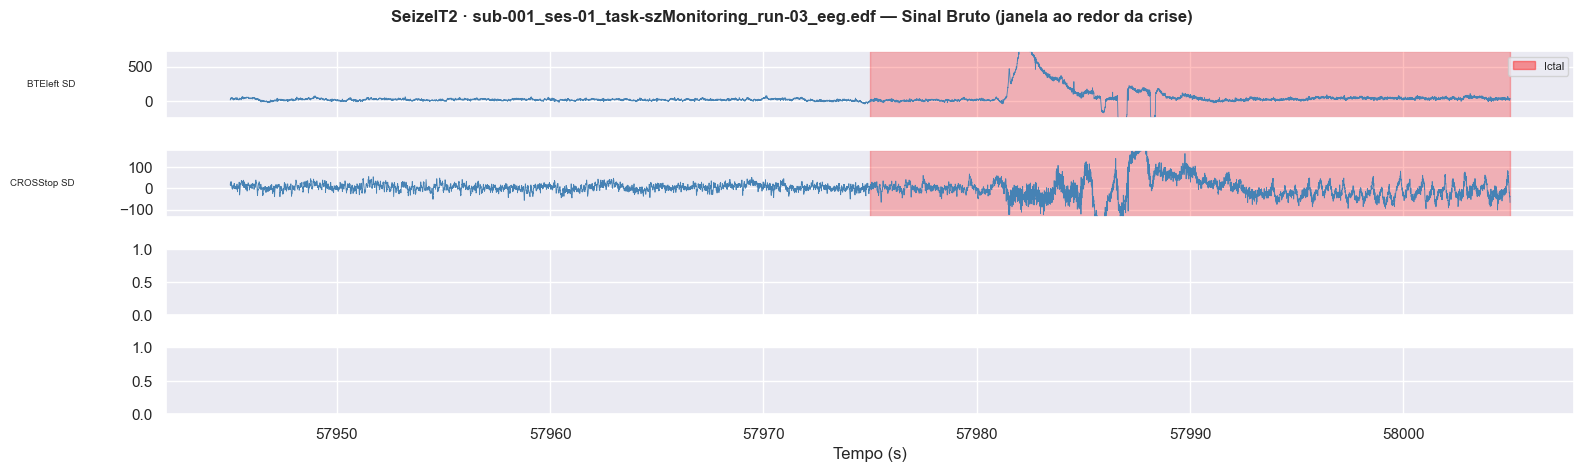

In [19]:
def plot_eeg_around_seizure(info, n_ch=4, t_win=60, title=''):
    data, sfreq, ch = info['data'], info['sfreq'], info['ch']
    seiz = info['seiz']
    s0   = max(0, seiz[0][0] - t_win // 2)
    i0   = int(s0 * sfreq)
    i1   = min(data.shape[1], i0 + int(t_win * sfreq))
    t    = np.linspace(s0, s0 + (i1-i0)/sfreq, i1-i0)

    step = max(1, len(ch) // n_ch)
    sel  = list(range(0, len(ch), step))[:n_ch]
    n_plot = len(sel)

    fig, axes = plt.subplots(n_ch, 1, figsize=(16, 2.4*n_plot), sharex=True)
    fig.suptitle(title or info['fname'], fontsize=12, fontweight='bold')
    if n_ch == 1: axes = [axes]

    for ax, ci in zip(axes, sel):
        seg = data[ci, i0:i1]
        ax.plot(t, seg, lw=0.6, color='steelblue')
        ax.set_ylabel(ch[ci], fontsize=7, rotation=0, labelpad=55, va='center')
        ylim = (np.percentile(seg,1)-20, np.percentile(seg,99)+20)
        ax.set_ylim(ylim)
        for s,e in seiz:
            ax.axvspan(max(s,s0), min(e,s0+t_win), alpha=0.25, color='red')
    axes[-1].set_xlabel('Tempo (s)')
    # Legenda manual
    from matplotlib.patches import Patch
    axes[0].legend(handles=[Patch(color='red',alpha=0.4,label='Ictal')],
                   loc='upper right', fontsize=8)
    plt.tight_layout(); plt.show()

for ds_name, info in datasets_eda.items():
    plot_eeg_around_seizure(info,
        title=f'{ds_name} · {info["fname"]} — Sinal Bruto (janela ao redor da crise)')

## 4.2 Comparação de PSD entre Datasets

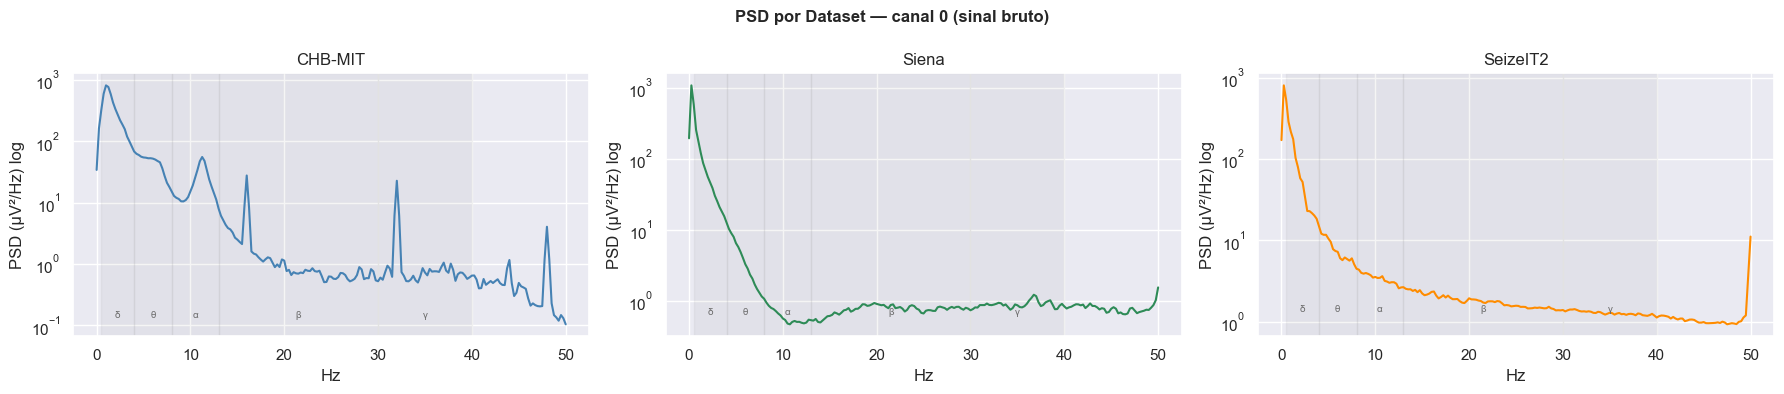

In [14]:
fig, axes = plt.subplots(1, len(datasets_eda), figsize=(6*len(datasets_eda), 4), sharey=False)
fig.suptitle('PSD por Dataset — canal 0 (sinal bruto)', fontsize=12, fontweight='bold')
if len(datasets_eda) == 1: axes = [axes]

colors = ['steelblue','seagreen','darkorange']
for ax, (ds_name, info), col in zip(axes, datasets_eda.items(), colors):
    sig  = info['data'][0]
    sf   = info['sfreq']
    f, p = welch(sig, fs=sf, nperseg=min(int(sf*4), len(sig)//2))
    mask = f <= 50
    ax.semilogy(f[mask], p[mask], color=col, lw=1.5)
    ax.set_title(ds_name); ax.set_xlabel('Hz')
    ax.set_ylabel('PSD (µV²/Hz) log')
    bands = {'δ':(0.5,4),'θ':(4,8),'α':(8,13),'β':(13,30),'γ':(30,40)}
    for bname,(bl,bh) in bands.items():
        ax.axvspan(bl,bh,alpha=0.08,color='gray')
        ax.text((bl+bh)/2, ax.get_ylim()[0]*2, bname, ha='center', fontsize=7, color='dimgray')

plt.tight_layout(); plt.show()

## 4.3 Tabela Comparativa dos Datasets

In [15]:
rows = []
for ds_name, info in datasets_eda.items():
    d, sf, ch = info['data'], info['sfreq'], info['ch']
    seiz = info['seiz']
    rows.append({
        'Dataset'     : ds_name,
        'Paciente'    : PILOT.get(ds_name, '—'),
        'Arquivo'     : os.path.basename(info['fname']),
        'fs (Hz)'     : int(sf),
        'Canais EEG'  : len(ch),
        'Duração (min)': round(info['dur']/60, 1),
        'Crises'      : len(seiz),
        'Dur. Crise(s)': ', '.join(f'{e-s}s' for s,e in seiz),
        'Notch (Hz)'  : int(info['notch']),
    })
pd.set_option('display.max_colwidth', 60)
df_comp = pd.DataFrame(rows)
display(df_comp)

,Dataset,Paciente,Arquivo,fs (Hz),Canais EEG,Duração (min),Crises,Dur. Crise(s),Notch (Hz)
0,CHB-MIT,—,chb01_03.edf,256,23,60.0,1,40s,60
1,Siena,PN00,PN00-1.edf,512,35,43.8,1,70s,50
2,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-03_eeg.edf,256,2,1083.0,1,72.0s,50


---
# Capítulo 5 — Pré-processamento

## 5.1 Funções de Filtragem

In [16]:
def notch_filter(data, sfreq, freq, Q=30):
    """Remove interferência de rede elétrica (IIR notch)."""
    b, a = iirnotch(freq, Q, sfreq)
    return filtfilt(b, a, data, axis=-1)

def highpass_filter(data, sfreq, cutoff=F_HP, order=F_ORDER):
    """Remove deriva DC e artefatos lentos (Butterworth passa-alta)."""
    sos = butter(order, cutoff, btype='high', fs=sfreq, output='sos')
    return sosfiltfilt(sos, data, axis=-1)

def lowpass_filter(data, sfreq, cutoff=F_LP, order=F_ORDER):
    """Remove EMG e ruído de alta frequência (Butterworth passa-baixa)."""
    sos = butter(order, cutoff, btype='low', fs=sfreq, output='sos')
    return sosfiltfilt(sos, data, axis=-1)

def preprocess(data, sfreq, notch_freq):
    """
    Pipeline: Notch → Passa-alta 0.5 Hz → Passa-baixa 40 Hz.
    data: (n_ch, n_samp) em µV.
    """
    out = notch_filter(data, sfreq, notch_freq)
    out = highpass_filter(out, sfreq)
    out = lowpass_filter(out, sfreq)
    return out

# ── Aplica em todos os arquivos EDA carregados ────────────────────────────────
for ds_name, info in datasets_eda.items():
    info['data_filt'] = preprocess(info['data'], info['sfreq'], info['notch'])
    rms_b = float(np.sqrt(np.mean(info['data'][0]**2)))
    rms_f = float(np.sqrt(np.mean(info['data_filt'][0]**2)))
    print(f"✅ {ds_name:10s} filtrado | RMS bruto={rms_b:.1f}µV → filtrado={rms_f:.1f}µV")

✅ CHB-MIT    filtrado | RMS bruto=40.7µV → filtrado=39.2µV
✅ Siena      filtrado | RMS bruto=34.4µV → filtrado=17.3µV
✅ SeizeIT2   filtrado | RMS bruto=37.2µV → filtrado=19.7µV


---
# Capítulo 6 — Rotulagem Temporal

```
╔════════════════════════════════════════════════════════════════════════════════════════╗
║  Linha do tempo de um EDF com uma crise                                                ║
║                                                                                        ║
║  ├── INTERICTAL ──┤  PRÉ-ICTAL (≤10 min) ├── ICTAL ─┤ PÓS-ICTAL (≤10min) ─┤            ║
║                   ↑                        ↑          ↑                     ↑          ║
║          seiz_start - PRE_SEC         seiz_start  seiz_end        seiz_end + POST_SEC  ║
╚════════════════════════════════════════════════════════════════════════════════════════╝
```

**Casos especiais:**
- Se a crise ocorre nos **primeiros < PRE_SEC** da gravação → pré-ictal = tudo disponível antes da crise (sem padding artificial).
- **Interictal** = amostras com distância ≥ IGAP_SEC de qualquer pré-ictal/ictal/pós-ictal.
- Amostras na zona de transição entre pós-ictal de uma crise e pré-ictal da próxima são marcadas como `unknown (-1)` e descartadas no janelamento.

**Classes:** `0=interictal  1=pré-ictal  2=ictal  3=pós-ictal  -1=unknown`

In [17]:
def build_label_array(n_samples, sfreq, seizure_intervals,
                      pre_sec=PRE_SEC, post_sec=POST_SEC, igap_sec=IGAP_SEC):
    """
    Constrói vetor de labels amostra-a-amostra.

    Estratégia vetorizada (eficiente para gravações longas):
      1. Inicia tudo como UNKNOWN.
      2. Marca ICTAL, PREICTAL, POSTICTAL em passagem direta.
      3. Uma amostra é INTERICTAL se:
         - ainda é UNKNOWN, E
         - está a pelo menos igap_sec de qualquer borda dos eventos marcados.
    """
    labels = np.full(n_samples, LBL['unknown'], dtype=np.int8)

    # ── Passagem 1: marca ictal / pré-ictal / pós-ictal ──────────────────────
    for (s_s, e_s) in seizure_intervals:
        i_s = int(s_s * sfreq)
        i_e = min(int(e_s * sfreq), n_samples)

        # Ictal
        labels[i_s:i_e] = LBL['ictal']

        # Pré-ictal (pode ser menor que pre_sec se crise no início)
        pre_start = max(0, i_s - int(pre_sec * sfreq))
        # Não sobrescreve ictal de uma crise anterior
        mask_pre = labels[pre_start:i_s] != LBL['ictal']
        seg = labels[pre_start:i_s]
        seg[mask_pre] = LBL['preictal']

        # Pós-ictal
        post_end = min(n_samples, i_e + int(post_sec * sfreq))
        mask_post = labels[i_e:post_end] != LBL['ictal']
        seg2 = labels[i_e:post_end]
        seg2[mask_post] = LBL['postictal']

    # ── Passagem 2: marca interictal com margem de segurança ─────────────────
    # Cria máscara de "evento ativo": amostras marcadas (≠ unknown)
    event_mask = labels != LBL['unknown']

    # Dilata event_mask por igap_sec usando convolução de bloco
    gap_samp = int(igap_sec * sfreq)
    if gap_samp > 0 and event_mask.any():
        from scipy.ndimage import binary_dilation
        struct = np.ones(gap_samp * 2 + 1, dtype=bool)
        near_event = binary_dilation(event_mask, structure=struct)
    else:
        near_event = event_mask

    # Interictal = unknown E não perto de evento
    interictal_mask = (~near_event) & (labels == LBL['unknown'])
    labels[interictal_mask] = LBL['interictal']

    return labels

# ── Testa com o primeiro arquivo CHB-MIT ─────────────────────────────────────
info_chb = datasets_eda.get('CHB-MIT')
if info_chb:
    lbl_chb = build_label_array(
        info_chb['data_filt'].shape[1], info_chb['sfreq'], info_chb['seiz'])

    u, c = np.unique(lbl_chb[lbl_chb >= 0], return_counts=True)
    print(f"📊 Rotulagem CHB-MIT · {info_chb['fname']} (fs={info_chb['sfreq']}Hz)")
    for lv, cnt in zip(u, c):
        dur = cnt / info_chb['sfreq']
        pct = cnt / len(lbl_chb[lbl_chb >= 0]) * 100
        print(f"   {LBL_NAMES[lv]:12s}: {cnt:8d} amostras = {dur:6.0f}s = {dur/60:.1f}min ({pct:.1f}%)")
    unk = (lbl_chb == -1).sum()
    print(f"   {'unknown':12s}: {unk:8d} amostras (descartadas no janelamento)")

MemoryError: 

## 6.1 Visualização da Rotulagem no Tempo

In [ ]:
def plot_label_timeline(data_filt, labels, sfreq, ch_names, title=''):
    n   = labels.shape[0]
    dur = n / sfreq / 60   # minutos
    ds  = max(1, int(sfreq * 1))   # 1 amostra/segundo para o plot

    t  = np.arange(0, n, ds) / sfreq / 60
    s  = data_filt[0, ::ds]
    lb = labels[::ds]

    color_map = {LBL['interictal']:'steelblue', LBL['preictal']:'orange',
                 LBL['ictal']:'crimson', LBL['postictal']:'purple',
                 LBL['unknown']:'lightgray'}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 5), sharex=True,
                                    gridspec_kw={'height_ratios':[3,1]})
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for lv in sorted(set(lb)):
        m = lb == lv
        ax1.scatter(t[m], s[m], s=0.2, c=color_map[lv],
                    label=LBL_NAMES.get(lv,'?'), alpha=0.7)
    ax1.set_ylabel(f'{ch_names[0]} (µV)', fontsize=9)
    ax1.legend(loc='upper right', markerscale=8, fontsize=8, ncol=5)

    for lv in [0,1,2,3]:
        m = labels[::ds] == lv
        ax2.scatter(t[m], np.full(m.sum(), lv), s=0.3, c=color_map[lv])
    ax2.set_yticks([0,1,2,3])
    ax2.set_yticklabels(['Inter.','Pré','Ictal','Pós'], fontsize=8)
    ax2.set_xlabel('Tempo (min)', fontsize=10)

    plt.tight_layout(); plt.show()

if info_chb:
    plot_label_timeline(info_chb['data_filt'], lbl_chb,
                        info_chb['sfreq'], info_chb['ch'],
                        title=f"CHB-MIT · {info_chb['fname']} — Rotulagem Temporal")

---
# Capítulo 7 — Janelamento com 50% de Overlap

**Regras de atribuição de label por janela:**
1. Janelas com qualquer amostra `unknown` → **descartadas**.
2. Janelas com ≥ 1 amostra `ictal` → label `ictal` (ictal tem prioridade).
3. Demais janelas: label da classe majoritária, desde que represente ≥ 80% das amostras (janelas mistas → descartadas).

In [ ]:
def extract_windows(data, labels, sfreq,
                    win_sec=WIN_SEC, overlap=OVERLAP,
                    min_pure=0.80):
    """
    Retorna (windows, win_labels, win_times_s):
        windows      : (N, n_ch, win_samples)  float32
        win_labels   : (N,)                    int8
        win_times_s  : (N,)                    float — segundo de início
    """
    ws   = int(win_sec * sfreq)
    step = max(1, int(ws * (1 - overlap)))

    wins, lbls, times = [], [], []
    for start in range(0, data.shape[1] - ws + 1, step):
        end    = start + ws
        seg_l  = labels[start:end]

        if (seg_l == LBL['unknown']).any():
            continue

        # Prioridade ictal
        if (seg_l == LBL['ictal']).any():
            lv = LBL['ictal']
        else:
            uv, uc = np.unique(seg_l, return_counts=True)
            mi = np.argmax(uc)
            if uc[mi] / ws < min_pure:
                continue
            lv = int(uv[mi])

        wins.append(data[:, start:end].astype(np.float32))
        lbls.append(lv)
        times.append(start / sfreq)

    if not wins:
        return (np.empty((0, data.shape[0], ws), np.float32),
                np.empty(0, np.int8), np.empty(0))
    return (np.stack(wins),
            np.array(lbls, np.int8),
            np.array(times))

# ── Teste ─────────────────────────────────────────────────────────────────────
if info_chb:
    W, L, T = extract_windows(info_chb['data_filt'], lbl_chb, info_chb['sfreq'])
    print(f"✅ Janelas extraídas: {len(W)} | shape: {W.shape}")
    u, c = np.unique(L, return_counts=True)
    for lv, cnt in zip(u, c):
        print(f"   {LBL_NAMES[lv]:12s}: {cnt:5d} janelas ({cnt/len(L)*100:.1f}%)")

    # Alerta desbalanceamento
    if len(c) > 1:
        ratio = c.max() / (c.min() + 1e-9)
        status = "⚠️  Severo" if ratio > 20 else "ℹ️  Moderado" if ratio > 5 else "✅ OK"
        print(f"\n   Ratio max/min: {ratio:.0f}x  → {status}")

---
# Capítulo 8 — Salvamento Nível 1 (Sinal Filtrado + Labels/Amostra)

O Nível 1 armazena o **sinal filtrado completo** (antes do janelamento) junto com o vetor de labels amostra-a-amostra.  
Isso permite re-janelamento futuro com outros parâmetros sem reprocessar os EDFs originais.

In [ ]:
def save_level1(data_filt, labels, sfreq, ch_names,
                dataset, patient, fname, out_dir=L1_DIR):
    """Salva sinal filtrado + labels/amostra em .npz + metadados JSON."""
    key  = f'{dataset}__{patient}__{os.path.splitext(os.path.basename(fname))[0]}'
    npz  = os.path.join(out_dir, key + '_L1.npz')
    meta = os.path.join(out_dir, key + '_L1_meta.json')

    if not os.path.exists(npz):
        np.savez_compressed(npz,
                            data=data_filt.astype(np.float32),
                            labels=labels,
                            sfreq=np.float32(sfreq),
                            ch_names=np.array(ch_names))
        m = {'dataset':dataset,'patient':patient,'source':str(fname),
             'sfreq':sfreq,'n_ch':len(ch_names),'n_samp':int(data_filt.shape[1]),
             'duration_s':round(data_filt.shape[1]/sfreq,2),
             'ch_names':ch_names,
             'label_dist':{LBL_NAMES[int(v)]:int(c)
                           for v,c in zip(*np.unique(labels[labels>=0],
                                                     return_counts=True))},
             'filter':{'hp_hz':F_HP,'lp_hz':F_LP,'notch_hz':
                       NOTCH.get(dataset,50),'order':F_ORDER}}
        with open(meta,'w') as f: json.dump(m, f, indent=2)
        print(f"💾 L1: {os.path.basename(npz)}")
    else:
        print(f"⏭️  Já existe: {os.path.basename(npz)}")
    return npz

# ── Pipeline completo: todos os datasets / pacientes piloto ──────────────────
l1_index = {}   # { 'CHBMIT__chb01__chb01_03': '/path/..._L1.npz', ... }

def run_l1_pipeline(dataset_name, patient, ann_dict,
                    edf_root, notch_freq):
    """
    Para cada arquivo com crise do paciente:
      1. Carrega EDF
      2. Filtra
      3. Rotula amostra-a-amostra
      4. Salva Nível 1
    """
    count = 0
    for fname, seiz in ann_dict.items():
        edf_path = os.path.join(edf_root, fname)
        if not os.path.exists(edf_path):
            print(f"  ⚠️  {fname} não encontrado, pulando.")
            continue
        data, sfreq, ch, dur = load_edf(edf_path)
        data_f = preprocess(data, sfreq, notch_freq)
        labels = build_label_array(data_f.shape[1], sfreq, seiz)
        npz    = save_level1(data_f, labels, sfreq, ch,
                             dataset_name, patient, fname)
        key    = f'{dataset_name}__{patient}__{os.path.splitext(os.path.basename(fname))[0]}'
        l1_index[key] = npz
        count += 1
    print(f"✅ {dataset_name} {patient}: {count} arquivos L1 salvos.")

# CHB-MIT
run_l1_pipeline('CHBMIT', PILOT['CHBMIT'], chbmit_ann,
                os.path.join(CHBMIT_DIR, PILOT['CHBMIT']),
                NOTCH['CHBMIT'])

# Siena
if siena_ann:
    run_l1_pipeline('Siena', PILOT['Siena'], siena_ann,
                    os.path.join(SIENA_DIR, PILOT['Siena']),
                    NOTCH['Siena'])

# SeizeIT2
if seizeit_ann:
    run_l1_pipeline('SeizeIT2', PILOT['SeizeIT2'], seizeit_ann,
                    seizeit_dir, NOTCH['SeizeIT2'])

print(f"\n📦 Total entradas L1: {len(l1_index)}")

---
# Capítulo 9 — Salvamento Nível 2 (Janelas + Labels/Janela)

Lê os NPZs do Nível 1 e extrai janelas. Salva um NPZ por paciente/dataset com **todas as janelas** — o undersampling será aplicado **apenas no treino** nos modelos.

In [ ]:
def save_level2(windows, win_labels, win_times, sfreq,
                dataset, patient, out_dir=L2_DIR):
    """Salva janelas rotuladas em .npz por paciente."""
    key  = f'{dataset}__{patient}'
    npz  = os.path.join(out_dir, key + '_L2.npz')
    meta = os.path.join(out_dir, key + '_L2_meta.json')

    np.savez_compressed(npz,
                        windows=windows,
                        labels=win_labels,
                        times=win_times)
    u, c = np.unique(win_labels, return_counts=True)
    m = {'dataset':dataset,'patient':patient,'sfreq':float(sfreq),
         'n_windows':int(len(windows)),'n_ch':int(windows.shape[1]),
         'win_samples':int(windows.shape[2]),
         'win_sec':WIN_SEC,'overlap':OVERLAP,
         'label_dist':{LBL_NAMES[int(v)]:int(ct) for v,ct in zip(u,c)}}
    with open(meta,'w') as f: json.dump(m, f, indent=2)
    print(f"💾 L2: {os.path.basename(npz)}  ({len(windows)} janelas)")
    return npz

# ── Agrupa entradas L1 por (dataset, patient) ─────────────────────────────────
from collections import defaultdict
l2_index = {}   # { 'CHBMIT__chb01': '/path/..._L2.npz' }

grouped = defaultdict(list)
for key, npz_path in l1_index.items():
    ds, pat, _ = key.split('__', 2)
    grouped[(ds, pat)].append(npz_path)

for (ds, pat), npz_list in grouped.items():
    all_wins, all_lbls, all_times = [], [], []
    sfreq_used = None
    for npz_path in npz_list:
        npz   = np.load(npz_path, allow_pickle=True)
        data  = npz['data']
        lbls  = npz['labels']
        sf    = float(npz['sfreq'])
        sfreq_used = sf
        W, L, T = extract_windows(data, lbls, sf)
        if len(W) > 0:
            all_wins.append(W)
            all_lbls.append(L)
            all_times.append(T)

    if all_wins:
        W_cat = np.concatenate(all_wins)
        L_cat = np.concatenate(all_lbls)
        T_cat = np.concatenate(all_times)
        npz2  = save_level2(W_cat, L_cat, T_cat, sfreq_used, ds, pat)
        l2_index[f'{ds}__{pat}'] = npz2

print(f"\n📦 Total entradas L2: {len(l2_index)}")

## 9.1 Distribuição Final de Classes por Paciente

In [ ]:
fig, axes = plt.subplots(1, max(1,len(l2_index)), figsize=(5*max(1,len(l2_index)), 4))
if len(l2_index) == 1: axes = [axes]
fig.suptitle('Distribuição de Janelas por Classe (Nível 2)', fontsize=12, fontweight='bold')

pal = {LBL['interictal']:'steelblue', LBL['preictal']:'orange',
       LBL['ictal']:'crimson',        LBL['postictal']:'purple'}

for ax, (key, npz_path) in zip(axes, l2_index.items()):
    npz = np.load(npz_path)
    L   = npz['labels']
    u, c = np.unique(L, return_counts=True)
    colors_bar = [pal.get(int(v),'gray') for v in u]
    bars = ax.bar([LBL_NAMES[int(v)] for v in u], c, color=colors_bar,
                  edgecolor='white', linewidth=0.5)
    ax.set_title(key.replace('__',' · '), fontsize=9)
    ax.set_ylabel('Janelas')
    for b, cnt in zip(bars, c):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                str(cnt), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout(); plt.show()

---
# Capítulo 10 — Extração de Features

Extraímos três grupos de features por canal em cada janela:

| Grupo | Features | Qtde/canal |
|-------|---------|-----------|
| **Temporal** | Mean, Std, Variance, RMS, Skewness, Kurtosis, Zero-crossing rate, Line length, Hjorth (Activity, Mobility, Complexity) | 10 |
| **Espectral** | Potência de 5 bandas (δ/θ/α/β/γ), Entropia espectral, Frequência dominante, Razões de bandas (θ/α, β/α, γ/β) | 10 |
| **Não-linear** | Sample Entropy, Hurst Exponent, DWT energia (db4, 4 níveis: D1–D4) | 6 |

**Total:** 26 features × n_canais por janela.

In [ ]:
# ── Features temporais ────────────────────────────────────────────────────────
def temporal_feats(sig):
    """10 features temporais."""
    d1 = np.diff(sig)
    d2 = np.diff(d1)
    act  = float(np.var(sig))
    mob  = float(np.sqrt(np.var(d1) / (np.var(sig) + 1e-10)))
    comp = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mob + 1e-10))
    return np.array([
        float(np.mean(sig)),
        float(np.std(sig)),
        float(np.var(sig)),
        float(np.sqrt(np.mean(sig**2))),           # RMS
        float(sp_skew(sig, bias=False)),
        float(sp_kurtosis(sig, fisher=True, bias=False)),
        float(np.sum(np.diff(np.signbit(sig))) / len(sig)),  # ZCR
        float(np.sum(np.abs(np.diff(sig)))),       # Line length
        act, mob,                                  # Hjorth Activity, Mobility
    ], dtype=np.float32)

# ── Features espectrais ───────────────────────────────────────────────────────
_BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

def spectral_feats(sig, sfreq):
    """10 features espectrais (PSD via Welch)."""
    nperseg = min(int(sfreq*4), max(int(sfreq), len(sig)//2))
    f, psd  = welch(sig, fs=sfreq, nperseg=nperseg)

    bp = {}
    for bname,(lo,hi) in _BANDS.items():
        idx = (f >= lo) & (f <= hi)
        bp[bname] = float(np.trapz(psd[idx], f[idx])) if idx.sum()>1 else 0.0

    total = sum(bp.values()) + 1e-10
    # Entropia espectral
    psd_norm = psd / (psd.sum() + 1e-10)
    psd_norm = psd_norm[psd_norm > 0]
    sp_ent   = float(-np.sum(psd_norm * np.log(psd_norm)))
    # Frequência dominante
    dom_f    = float(f[np.argmax(psd)])
    # Razões
    return np.array([
        bp['delta'], bp['theta'], bp['alpha'], bp['beta'], bp['gamma'],
        sp_ent, dom_f,
        bp['theta'] / (bp['alpha'] + 1e-10),
        bp['beta']  / (bp['alpha'] + 1e-10),
        bp['gamma'] / (bp['beta']  + 1e-10),
    ], dtype=np.float32)

# ── Features não-lineares ─────────────────────────────────────────────────────
def sample_entropy(sig, m=2, r_factor=0.2):
    """Sample Entropy (SampEn) — medida de irregularidade."""
    r = r_factor * float(np.std(sig))
    N = len(sig)
    def _count(template_len):
        count = 0
        for i in range(N - template_len):
            dist = np.max(np.abs(sig[i:i+template_len, None] -
                                 sig[:N-template_len, None].T +
                                 sig[i:i+template_len, None].T -
                                 sig[:N-template_len, None].T), axis=0)
            # Simples: distância Chebyshev entre templates
            template = sig[i:i+template_len]
            dists = [np.max(np.abs(template - sig[j:j+template_len]))
                     for j in range(N - template_len) if j != i]
            count += sum(1 for d in dists if d <= r)
        return count
    # Versão simplificada (rápida): usa apenas janela central
    B = _count(m)
    A = _count(m + 1)
    if B == 0: return 0.0
    return float(-np.log((A + 1e-10) / (B + 1e-10)))

def hurst_exponent(sig):
    """Expoente de Hurst via R/S analysis."""
    N = len(sig)
    if N < 20: return 0.5
    lags  = np.logspace(1, np.log10(N//2), num=10, dtype=int)
    lags  = np.unique(np.clip(lags, 2, N//2))
    rs    = []
    for lag in lags:
        sub = sig[:lag]
        mean_sub = sub.mean()
        devs = np.cumsum(sub - mean_sub)
        R    = devs.max() - devs.min()
        S    = sub.std() + 1e-10
        rs.append(R / S)
    if len(rs) < 2: return 0.5
    try:
        h, _ = np.polyfit(np.log(lags[:len(rs)]), np.log(rs), 1)
    except Exception:
        h = 0.5
    return float(np.clip(h, 0, 1))

def dwt_energy_feats(sig, wavelet='db4', level=4):
    """Energia de 4 sub-bandas de detalhe DWT."""
    coeffs = pywt.wavedec(sig.astype(np.float64), wavelet, level=level)
    # D1..D4 (detalhe, do mais fino ao mais grosso)
    return np.array([float(np.sum(c**2)) for c in coeffs[1:level+1]],
                    dtype=np.float32)

def nonlinear_feats(sig, sfreq):
    """6 features não-lineares: SampEn + Hurst + 4 energias DWT."""
    se = sample_entropy(sig[:min(len(sig), int(sfreq*2))])  # limita para velocidade
    hu = hurst_exponent(sig)
    dw = dwt_energy_feats(sig)
    return np.array([se, hu, *dw], dtype=np.float32)

print("✅ Funções de features definidas")
print(f"   Temporal  : 10 features/canal")
print(f"   Espectral : 10 features/canal")
print(f"   Não-linear:  6 features/canal")
print(f"   Total     : 26 features/canal")

In [ ]:
def extract_features_window(window, sfreq):
    """
    Extrai features de uma janela (n_ch, n_samp).
    Retorna vetor 1D de tamanho n_ch * 26.
    """
    feats = []
    for ch in range(window.shape[0]):
        sig = window[ch].astype(np.float64)
        feats.append(temporal_feats(sig))
        feats.append(spectral_feats(sig, sfreq))
        feats.append(nonlinear_feats(sig, sfreq))
    return np.concatenate(feats).astype(np.float32)

def extract_features_batch(windows, sfreq, desc='Features'):
    """Extrai features de todas as janelas. Retorna (N, n_ch*26)."""
    return np.stack([
        extract_features_window(w, sfreq)
        for w in tqdm(windows, desc=desc, leave=False)
    ])

# ── Extrai e salva features para cada paciente ────────────────────────────────
feat_index = {}   # { 'CHBMIT__chb01': ('path_X.npy','path_y.npy') }

for key, npz_path in l2_index.items():
    npz  = np.load(npz_path)
    W    = npz['windows']
    L    = npz['labels']
    sf   = float(npz['sfreq'] if 'sfreq' in npz else
                 np.load(list(l1_index.values())[0])['sfreq'])
    # Lê sfreq do meta JSON
    meta_path = npz_path.replace('_L2.npz', '_L2_meta.json')
    if os.path.exists(meta_path):
        with open(meta_path) as f: sf = json.load(f).get('sfreq', sf)

    feat_file = os.path.join(FEAT_DIR, key + '_X.npy')
    lbl_file  = os.path.join(FEAT_DIR, key + '_y.npy')

    if not os.path.exists(feat_file):
        print(f"Extraindo features: {key} ({len(W)} janelas, {W.shape[1]} canais) ...")
        X = extract_features_batch(W, sf, desc=key)
        np.save(feat_file, X)
        np.save(lbl_file, L)
        print(f"  ✅ {X.shape}  salvo em {os.path.basename(feat_file)}")
    else:
        print(f"⏭️  Já existe: {os.path.basename(feat_file)}")

    feat_index[key] = (feat_file, lbl_file)

print(f"\n📦 Features prontas: {len(feat_index)} paciente(s)")

---
# Capítulo 11 — Modelos Baseline

## 11.1 Estratégia de Validação: LOSO-CV

**Leave-One-Subject-Out (LOSO)**: cada paciente é usado uma vez como teste, os demais como treino.  
Com paciente único piloto, usamos **Leave-One-File-Out (LOFO)** — cada arquivo EDF é test fold.

**Foco:** predição de crise → classificamos **pré-ictal (1) vs interictal (0)** (problema binário principal).  
Janelas ictais e pós-ictais são excluídas do treino/teste dos modelos clássicos.

> Para a CNN, usamos o sinal bruto das janelas (dados L2).

In [ ]:
from sklearn.ensemble           import RandomForestClassifier
from sklearn.svm                import SVC
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import (classification_report, roc_auc_score,
                                         confusion_matrix, f1_score,
                                         precision_score, recall_score)
from sklearn.pipeline           import Pipeline
from sklearn.utils.class_weight import compute_class_weight

def compute_metrics(y_true, y_pred, y_prob=None):
    """Retorna dict com métricas padrão de predição de crise."""
    m = {
        'sensitivity': float(recall_score(y_true, y_pred, pos_label=1,
                                          zero_division=0)),
        'specificity': float(recall_score(y_true, y_pred, pos_label=0,
                                          zero_division=0)),
        'f1_preictal': float(f1_score(y_true, y_pred, pos_label=1,
                                      zero_division=0)),
        'accuracy'   : float(np.mean(y_true == y_pred)),
    }
    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            m['auc'] = float(roc_auc_score(y_true, y_prob))
        except Exception:
            m['auc'] = float('nan')
    return m

def loso_eval(feat_index, model_factory, model_name='Model',
              use_postictal=False, balance='weight'):
    """
    LOSO-CV sobre os pacientes em feat_index.
    Binário: 0=interictal, 1=pré-ictal.
    use_postictal: inclui pós-ictal como interictal (label 0).
    balance: 'weight' (class_weight) | 'undersample' | None
    """
    results = []

    patient_keys = list(feat_index.keys())

    for test_key in patient_keys:
        # ── Treino: todos exceto test_key ────────────────────────────────────
        Xtr_list, ytr_list = [], []
        for key, (fx, fy) in feat_index.items():
            if key == test_key: continue
            X_k = np.load(fx)
            y_k = np.load(fy)
            # Seleciona interictal (0) e pré-ictal (1)
            mask = np.isin(y_k, [LBL['interictal'], LBL['preictal']])
            if use_postictal:
                # Trata pós-ictal como interictal
                y_k_b = np.where(y_k == LBL['postictal'], LBL['interictal'], y_k)
                mask  = np.isin(y_k, [LBL['interictal'], LBL['preictal'], LBL['postictal']])
            else:
                y_k_b = y_k
            X_k = X_k[mask]; y_k_b = y_k_b[mask]
            Xtr_list.append(X_k); ytr_list.append(y_k_b)

        if not Xtr_list:
            continue

        X_tr = np.concatenate(Xtr_list)
        y_tr = np.concatenate(ytr_list).astype(int)

        # Undersampling leve (ratio 1:5 interictal:pré-ictal)
        if balance == 'undersample':
            idx_pre  = np.where(y_tr == 1)[0]
            idx_int  = np.where(y_tr == 0)[0]
            n_int    = min(len(idx_int), len(idx_pre) * 5)
            rng      = np.random.default_rng(RANDOM_SEED)
            idx_int  = rng.choice(idx_int, n_int, replace=False)
            idx_keep = np.concatenate([idx_pre, idx_int])
            X_tr, y_tr = X_tr[idx_keep], y_tr[idx_keep]

        # ── Teste ─────────────────────────────────────────────────────────────
        fx_te, fy_te = feat_index[test_key]
        X_te = np.load(fx_te)
        y_te = np.load(fy_te).astype(int)
        mask_te = np.isin(y_te, [LBL['interictal'], LBL['preictal']])
        if use_postictal:
            y_te = np.where(y_te == LBL['postictal'], LBL['interictal'], y_te)
            mask_te = np.isin(y_te, [0, 1])
        X_te = X_te[mask_te]; y_te = y_te[mask_te]

        if len(np.unique(y_te)) < 2:
            print(f"  ⚠️  {test_key}: apenas 1 classe no teste, pulando.")
            continue

        # NaN guard
        X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
        X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

        clf = model_factory(y_tr)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        y_prob = (clf.predict_proba(X_te)[:,1]
                  if hasattr(clf, 'predict_proba') else None)

        m = compute_metrics(y_te, y_pred, y_prob)
        m['test_patient']  = test_key
        m['n_train']       = len(y_tr)
        m['n_test']        = len(y_te)
        m['n_pre_test']    = int((y_te == 1).sum())
        m['n_inter_test']  = int((y_te == 0).sum())
        results.append(m)
        print(f"  {test_key:30s} | sens={m['sensitivity']:.2f} spec={m['specificity']:.2f} "
              f"f1={m['f1_preictal']:.2f} auc={m.get('auc',float('nan')):.2f}")

    return pd.DataFrame(results)

## 11.2 Random Forest

In [ ]:
print("=" * 60)
print("Modelo 1 — Random Forest (LOSO)")
print("=" * 60)

def rf_factory(y_tr):
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = {int(c): float(w) for c, w in zip(np.unique(y_tr), cw)}
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            class_weight=cw_dict,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ))
    ])
    return pipe

df_rf = loso_eval(feat_index, rf_factory, 'RF', balance='undersample')
print("\n📊 Random Forest — Resumo:")
display(df_rf.drop(columns=['test_patient']).describe().loc[['mean','std']].round(3))

## 11.3 SVM

In [ ]:
print("=" * 60)
print("Modelo 2 — SVM RBF (LOSO)")
print("=" * 60)

def svm_factory(y_tr):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_SEED,
        ))
    ])
    return pipe

df_svm = loso_eval(feat_index, svm_factory, 'SVM', balance='undersample')
print("\n📊 SVM — Resumo:")
display(df_svm.drop(columns=['test_patient']).describe().loc[['mean','std']].round(3))

## 11.4 CNN 1D (PyTorch)

A CNN opera diretamente sobre o **sinal bruto filtrado** (janelas do Nível 2), sem features manuais.  
Arquitetura leve compatível com cenário vestível: 3 blocos Conv1D + GlobalAvgPool + FC.

> **Dado de entrada:** (batch, n_canais, win_samples) — o sinal filtrado em µV.

In [ ]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
    TORCH_OK = True
    DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"✅ PyTorch disponível — device: {DEVICE}")
except ImportError:
    TORCH_OK = False
    print("⚠️  PyTorch não instalado — pulando CNN.")

In [ ]:
if TORCH_OK:
    class EEG_CNN1D(nn.Module):
        """
        CNN 1D leve para predição de crise (binário: interictal vs pré-ictal).
        Entrada: (B, C, T) — canais × amostras por janela.
        """
        def __init__(self, n_channels, win_samples, n_classes=2):
            super().__init__()
            self.convs = nn.Sequential(
                # Bloco 1 — filtros temporais largos
                nn.Conv1d(n_channels, 32, kernel_size=25, padding=12),
                nn.BatchNorm1d(32), nn.GELU(),
                nn.MaxPool1d(4),

                # Bloco 2 — filtros médios
                nn.Conv1d(32, 64, kernel_size=11, padding=5),
                nn.BatchNorm1d(64), nn.GELU(),
                nn.MaxPool1d(4),

                # Bloco 3 — filtros finos
                nn.Conv1d(64, 128, kernel_size=5, padding=2),
                nn.BatchNorm1d(128), nn.GELU(),
                nn.AdaptiveAvgPool1d(1),   # Global Average Pooling
            )
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128, 64), nn.GELU(), nn.Dropout(0.4),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            return self.head(self.convs(x))

    print("✅ EEG_CNN1D definida")

In [ ]:
if TORCH_OK:
    def train_cnn_loso(l2_index, n_epochs=20, batch_size=64, lr=1e-3):
        """
        LOSO-CV com CNN 1D.
        Usa dados L2 (sinal bruto filtrado), apenas interictal vs pré-ictal.
        """
        results_cnn = []
        patient_keys = list(l2_index.keys())

        for test_key in patient_keys:
            print(f"\n  ▶ Teste: {test_key}")

            # ── Treino ─────────────────────────────────────────────────────────
            Xtr_list, ytr_list = [], []
            for key, npz_path in l2_index.items():
                if key == test_key: continue
                npz = np.load(npz_path)
                W, L = npz['windows'], npz['labels'].astype(int)
                mask = np.isin(L, [LBL['interictal'], LBL['preictal']])
                W, L = W[mask], L[mask]
                Xtr_list.append(W); ytr_list.append(L)

            if not Xtr_list: continue

            X_tr = np.concatenate(Xtr_list)
            y_tr = np.concatenate(ytr_list)

            # Undersampling 1:5
            idx_pre = np.where(y_tr == LBL['preictal'])[0]
            idx_int = np.where(y_tr == LBL['interictal'])[0]
            n_int   = min(len(idx_int), len(idx_pre) * 5)
            rng     = np.random.default_rng(RANDOM_SEED)
            idx_int = rng.choice(idx_int, n_int, replace=False)
            idx_k   = np.concatenate([idx_pre, idx_int])
            X_tr, y_tr = X_tr[idx_k], y_tr[idx_k]

            n_ch, n_samp = X_tr.shape[1], X_tr.shape[2]

            # Normalização por canal (média 0, std 1 por canal de treino)
            ch_mean = X_tr.mean(axis=(0,2), keepdims=True)
            ch_std  = X_tr.std(axis=(0,2),  keepdims=True) + 1e-6
            X_tr_n  = (X_tr - ch_mean) / ch_std

            # ── Teste ──────────────────────────────────────────────────────────
            npz_te = np.load(l2_index[test_key])
            X_te, y_te = npz_te['windows'], npz_te['labels'].astype(int)
            mask_te = np.isin(y_te, [LBL['interictal'], LBL['preictal']])
            X_te, y_te = X_te[mask_te], y_te[mask_te]

            if len(np.unique(y_te)) < 2:
                print(f"    ⚠️  Apenas 1 classe no teste, pulando.")
                continue

            X_te_n = (X_te - ch_mean) / ch_std

            # ── Datasets ──────────────────────────────────────────────────────
            # Remap labels para 0/1
            y_tr_b = (y_tr == LBL['preictal']).astype(np.int64)
            y_te_b = (y_te == LBL['preictal']).astype(np.int64)

            Xt = torch.tensor(X_tr_n, dtype=torch.float32)
            yt = torch.tensor(y_tr_b, dtype=torch.long)
            Xe = torch.tensor(X_te_n, dtype=torch.float32)
            ye = torch.tensor(y_te_b, dtype=torch.long)

            # Weighted sampler para balancear mini-batches
            class_counts = np.bincount(y_tr_b)
            weights_s    = 1.0 / (class_counts[y_tr_b] + 1e-10)
            sampler      = WeightedRandomSampler(weights_s, len(weights_s))

            loader_tr = DataLoader(TensorDataset(Xt, yt),
                                   batch_size=batch_size, sampler=sampler)
            loader_te = DataLoader(TensorDataset(Xe, ye),
                                   batch_size=256, shuffle=False)

            # ── Modelo ────────────────────────────────────────────────────────
            model = EEG_CNN1D(n_ch, n_samp).to(DEVICE)
            # Peso da classe positiva (pré-ictal)
            pos_w  = torch.tensor([1.0, len(idx_int)/(len(idx_pre)+1e-10)],
                                   dtype=torch.float32).to(DEVICE)
            crit   = nn.CrossEntropyLoss(weight=pos_w)
            opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
            sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

            # ── Treino ────────────────────────────────────────────────────────
            model.train()
            for epoch in range(n_epochs):
                ep_loss = 0.0
                for Xb, yb in loader_tr:
                    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                    opt.zero_grad()
                    loss = crit(model(Xb), yb)
                    loss.backward()
                    opt.step()
                    ep_loss += loss.item()
                sched.step()
                if (epoch+1) % 5 == 0:
                    print(f"    Epoch {epoch+1:3d}/{n_epochs} | loss={ep_loss/len(loader_tr):.4f}")

            # ── Avaliação ─────────────────────────────────────────────────────
            model.eval()
            all_pred, all_prob = [], []
            with torch.no_grad():
                for Xb, _ in loader_te:
                    logits = model(Xb.to(DEVICE))
                    probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
                    preds  = logits.argmax(dim=1).cpu().numpy()
                    all_pred.extend(preds); all_prob.extend(probs)

            y_pred_cnn = np.array(all_pred)
            y_prob_cnn = np.array(all_prob)
            y_te_np    = y_te_b.numpy() if hasattr(y_te_b,'numpy') else y_te_b

            m = compute_metrics(y_te_np, y_pred_cnn, y_prob_cnn)
            m['test_patient'] = test_key
            m['n_train'] = len(y_tr_b); m['n_test'] = len(y_te_b)
            m['n_pre_test']   = int(y_te_b.sum())
            m['n_inter_test'] = int((y_te_b==0).sum())
            results_cnn.append(m)
            print(f"    ✅ sens={m['sensitivity']:.2f} spec={m['specificity']:.2f} "
                  f"f1={m['f1_preictal']:.2f} auc={m.get('auc',float('nan')):.2f}")

        return pd.DataFrame(results_cnn)

    df_cnn = train_cnn_loso(l2_index, n_epochs=20)
    print("\n📊 CNN 1D — Resumo:")
    if not df_cnn.empty:
        display(df_cnn.drop(columns=['test_patient']).describe().loc[['mean','std']].round(3))

---
# Capítulo 12 — Resultados Comparativos

In [ ]:
# ── Consolida resultados ─────────────────────────────────────────────────────
all_results = []
for tag, df in [('Random Forest', df_rf), ('SVM', df_svm)]:
    if df is not None and len(df) > 0:
        df2 = df.copy(); df2['model'] = tag
        all_results.append(df2)

if TORCH_OK and 'df_cnn' in dir() and not df_cnn.empty:
    df2 = df_cnn.copy(); df2['model'] = 'CNN 1D'
    all_results.append(df2)

if all_results:
    df_all = pd.concat(all_results, ignore_index=True)

    # ── Tabela resumo ─────────────────────────────────────────────────────────
    metrics = ['sensitivity','specificity','f1_preictal','accuracy']
    if 'auc' in df_all.columns:
        metrics.append('auc')

    summary = (df_all.groupby('model')[metrics]
                     .agg(['mean','std'])
                     .round(3))
    print("\n📊 Resumo por Modelo (média ± std sobre folds LOSO):")
    display(summary)

    # ── Gráfico comparativo ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 4))
    fig.suptitle('Comparação de Modelos — LOSO-CV\n(Pré-ictal vs Interictal)',
                 fontsize=12, fontweight='bold')

    pal_models = {'Random Forest':'steelblue','SVM':'seagreen','CNN 1D':'darkorange'}
    for ax, met in zip(axes, metrics):
        means = df_all.groupby('model')[met].mean()
        stds  = df_all.groupby('model')[met].std().fillna(0)
        colors_m = [pal_models.get(m,'gray') for m in means.index]
        bars = ax.bar(means.index, means.values,
                      yerr=stds.values, color=colors_m,
                      capsize=4, edgecolor='white')
        ax.set_ylim(0,1.05)
        ax.set_title(met.replace('_',' ').title(), fontsize=9)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=15)
        for b, v in zip(bars, means.values):
            ax.text(b.get_x()+b.get_width()/2, v+0.02,
                    f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout(); plt.show()

    # ── Detalhes por paciente ─────────────────────────────────────────────────
    print("\n📋 Detalhes por Paciente/Fold:")
    display(df_all[['model','test_patient','sensitivity','specificity',
                    'f1_preictal','n_pre_test','n_inter_test']].sort_values(
                    ['model','test_patient']).round(3))
else:
    print("Nenhum resultado disponível ainda.")

---
# Resumo e Próximos Passos

## ✅ O que foi implementado

| Etapa | Status |
|-------|--------|
| Download CHB-MIT (S3 / physionet-open) | ✅ |
| Download Siena (HTTPS / physionet) | ✅ |
| Download SeizeIT2 (S3 / OpenNeuro, BIDS) | ✅ |
| Parser CHB-MIT `summary.txt` | ✅ |
| Parser Siena `Seizures-list-PNXX.txt` (relógio → offset) | ✅ |
| Parser SeizeIT2 `_events.tsv` (BIDS) | ✅ |
| EDA: plots, PSD, tabela comparativa | ✅ |
| Pré-processamento: Notch + HP + LP | ✅ |
| Rotulagem: interictal / pré-ictal / ictal / pós-ictal | ✅ |
| Caso especial: crise no início da gravação | ✅ |
| Janelamento 4 s · 50 % overlap | ✅ |
| Salvamento L1 (sinal filtrado) | ✅ |
| Salvamento L2 (janelas) | ✅ |
| Features: temporal + espectral + não-linear (26/canal) | ✅ |
| LOSO-CV · Random Forest | ✅ |
| LOSO-CV · SVM RBF | ✅ |
| LOSO-CV · CNN 1D (sinal bruto) | ✅ |
| Gráficos comparativos | ✅ |

## 🔜 Próximos Passos (Notebook 3)
- Adicionar mais pacientes (CHB-MIT chb01–chb05, Siena PN00–PN05, SeizeIT2 multi-subject)
- Cenários de generalização cross-dataset (Treino CHB-MIT → Teste Siena)
- Redução de canais: 19 → 8 → 4 → 2 (simulação EEG vestível)
- Features de conectividade (Coherence, PLI)
- Modelos mais profundos: TCN, CNN-LSTM